---
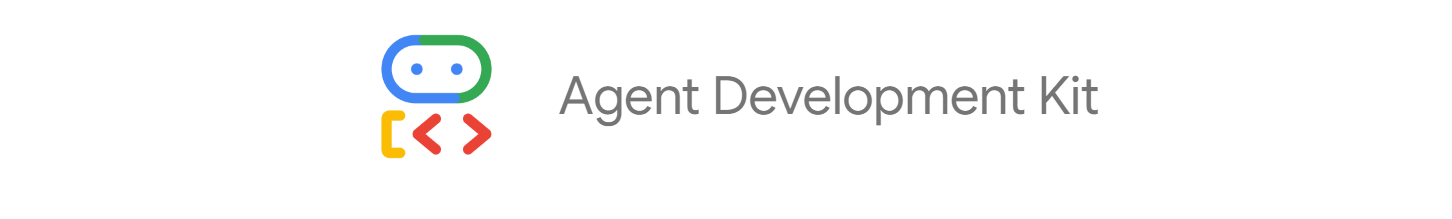

---

# Events in ADK
Events are the fundamental units of information flow within the **Agent Development Kit (`ADK`)**. They represent every significant occurrence during an agent's interaction lifecycle, from initial user input to the final response and all the steps in between. Understanding events is crucial because they are the primary way components communicate, state is managed, and control flow is directed.

### What Events Are and Why They Matter
An `Event` in ADK is an immutable record representing a specific point in the agent's execution. It captures user messages, agent replies, requests to use tools (function calls), tool results, state changes, control signals, and errors.

> Technically, it's an instance of the `google.adk.events.Event` class, which builds upon the basic `LlmResponse` structure by adding essential ADK-specific metadata and an `actions` payload.

```Python
# Conceptual Structure of an Event (Python)
# from google.adk.events import Event, EventActions
# from google.genai import types

# class Event(LlmResponse): # Simplified view
#     # --- LlmResponse fields ---
#     content: Optional[types.Content]
#     partial: Optional[bool]
#     # ... other response fields ...

#     # --- ADK specific additions ---
#     author: str          # 'user' or agent name
#     invocation_id: str   # ID for the whole interaction run
#     id: str              # Unique ID for this specific event
#     timestamp: float     # Creation time
#     actions: EventActions # Important for side-effects & control
#     branch: Optional[str] # Hierarchy path
#     # ...
```

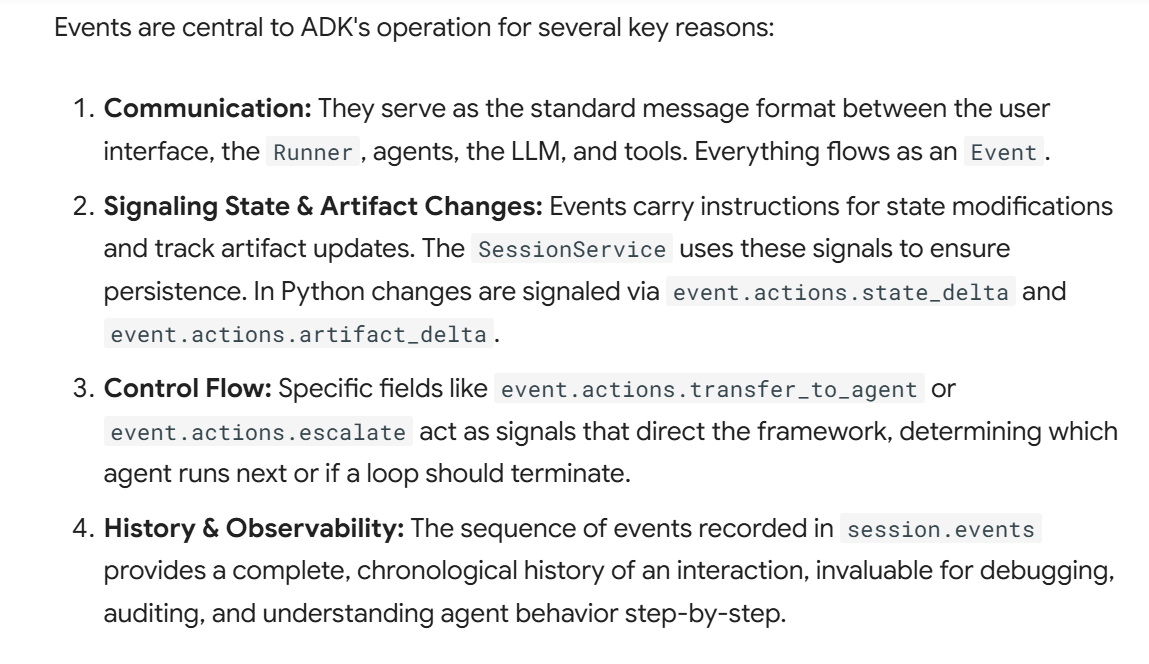 

> In essence, the entire process, from a user's query to the agent's final answer, is orchestrated through the generation, interpretation, and processing of `Event` objects.

---

## Understanding and Using Events
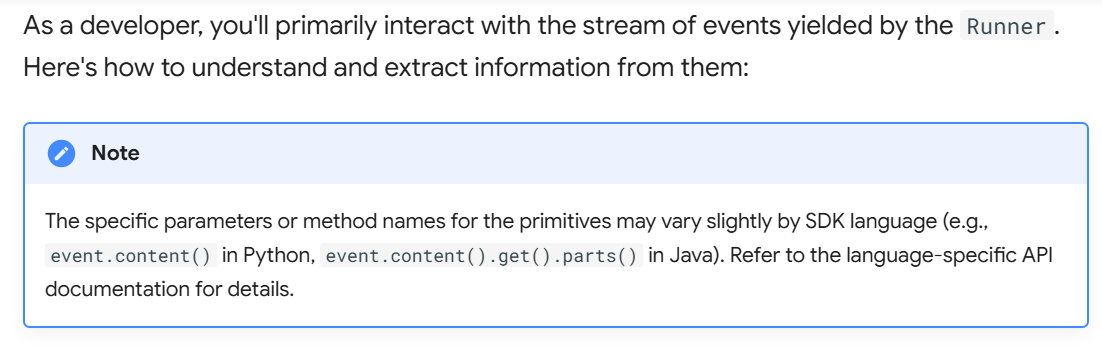 <br> 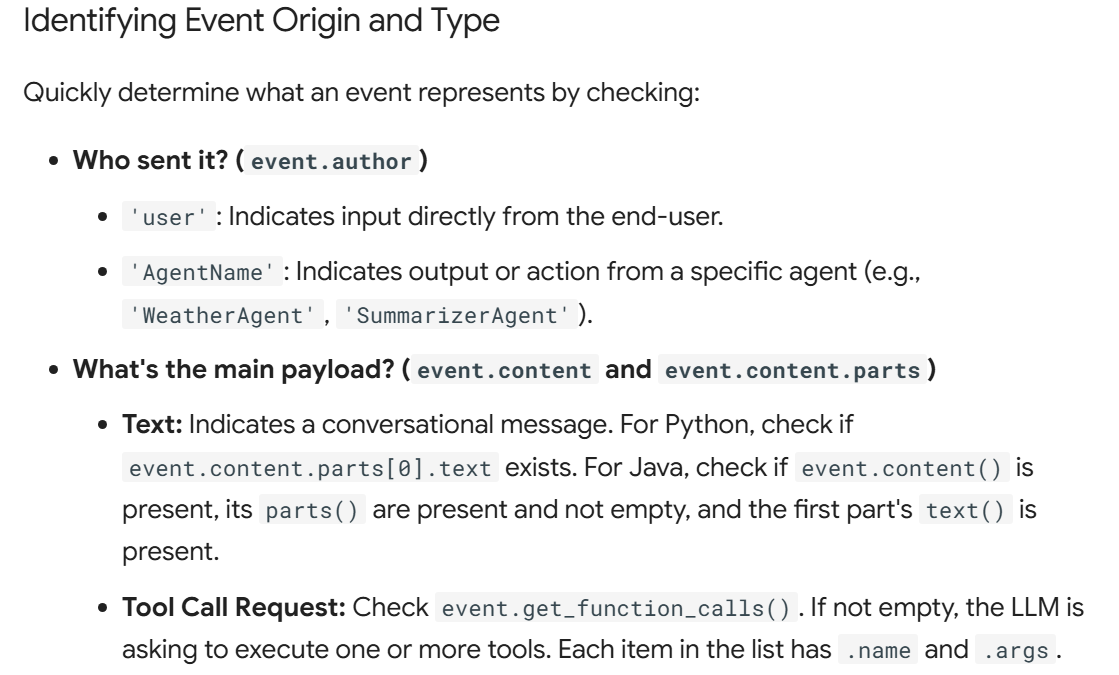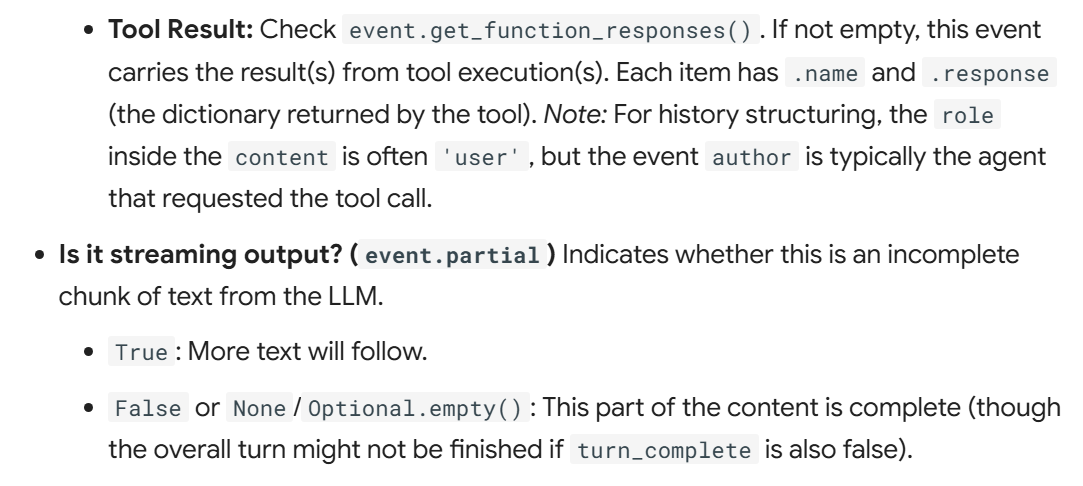 <br><br>

```Python
# Pseudocode: Basic event identification (Python)
# async for event in runner.run_async(...):
#     print(f"Event from: {event.author}")
#
#     if event.content and event.content.parts:
#         if event.get_function_calls():
#             print("  Type: Tool Call Request")
#         elif event.get_function_responses():
#             print("  Type: Tool Result")
#         elif event.content.parts[0].text:
#             if event.partial:
#                 print("  Type: Streaming Text Chunk")
#             else:
#                 print("  Type: Complete Text Message")
#         else:
#             print("  Type: Other Content (e.g., code result)")
#     elif event.actions and (event.actions.state_delta or event.actions.artifact_delta):
#         print("  Type: State/Artifact Update")
#     else:
#         print("  Type: Control Signal or Other")
```

---

## Extracting Key Information
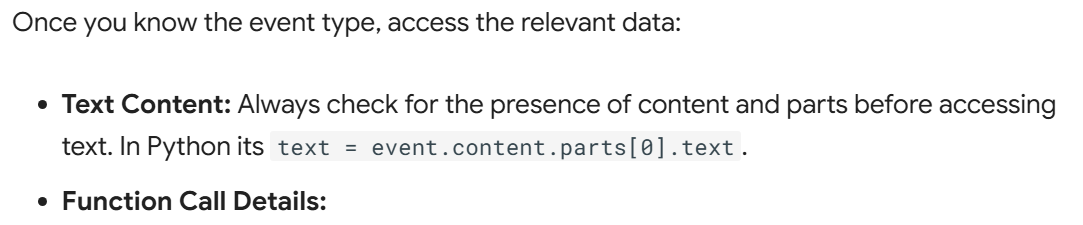

```Python
calls = event.get_function_calls()
if calls:
    for call in calls:
        tool_name = call.name
        arguments = call.args # This is usually a dictionary
        print(f"  Tool: {tool_name}, Args: {arguments}")
        # Application might dispatch execution based on this
```

**Function Response Details:**
```Python
responses = event.get_function_responses()
if responses:
    for response in responses:
        tool_name = response.name
        result_dict = response.response # The dictionary returned by the tool
        print(f"  Tool Result: {tool_name} -> {result_dict}")
```

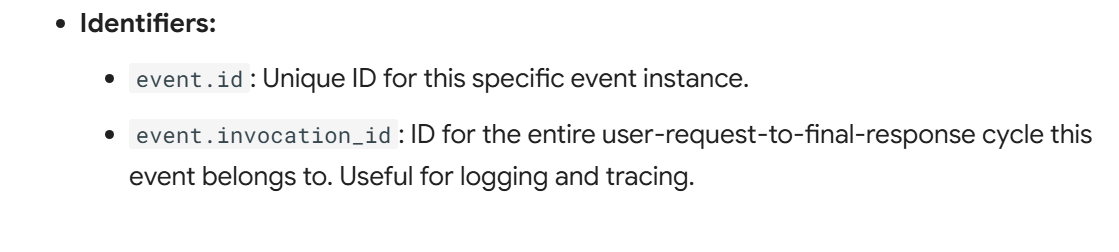

---

## Detecting Actions and Side Effects
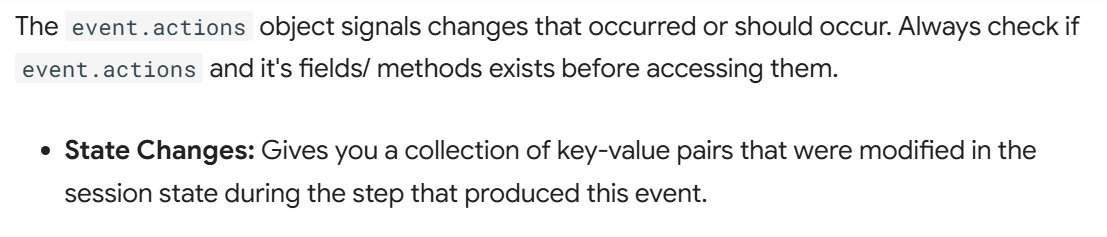

`delta = event.actions.state_delta (a dictionary of {key: value} pairs).`

```Python
if event.actions and event.actions.state_delta:
    print(f"  State changes: {event.actions.state_delta}")
    # Update local UI or application state if necessary
```

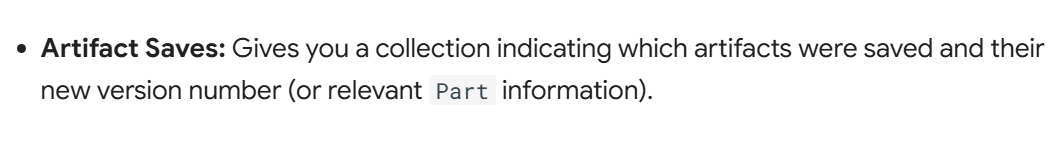

`artifact_changes = event.actions.artifact_delta (a dictionary of {filename: version}).`

```Python
if event.actions and event.actions.artifact_delta:
    print(f"  Artifacts saved: {event.actions.artifact_delta}")
    # UI might refresh an artifact list
```

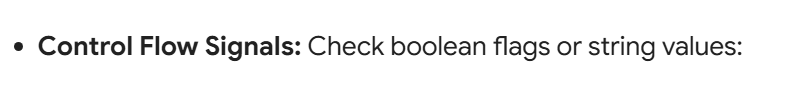

- `event.actions.transfer_to_agent (string): Control should pass to the named agent.`
- `event.actions.escalate (bool): A loop should terminate.`
- `event.actions.skip_summarization (bool): A tool result should not be summarized by the LLM.`

```Python
if event.actions:
    if event.actions.transfer_to_agent:
        print(f"  Signal: Transfer to {event.actions.transfer_to_agent}")
    if event.actions.escalate:
        print("  Signal: Escalate (terminate loop)")
    if event.actions.skip_summarization:
        print("  Signal: Skip summarization for tool result")
```

---

## Determining if an Event is a "Final" Response
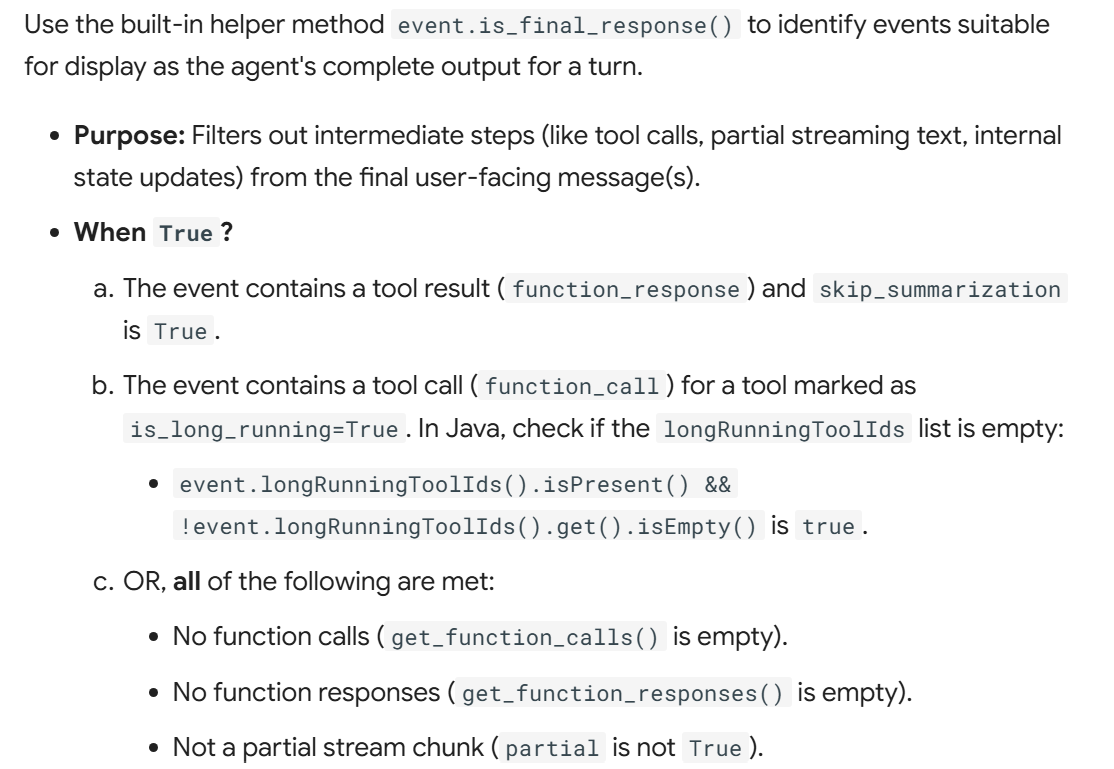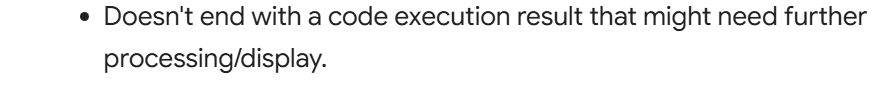 <br><br>

> **Usage:** Filter the event stream in your application logic.

```Python
# Pseudocode: Handling final responses in application (Python)
# full_response_text = ""
# async for event in runner.run_async(...):
#     # Accumulate streaming text if needed...
#     if event.partial and event.content and event.content.parts and event.content.parts[0].text:
#         full_response_text += event.content.parts[0].text
#
#     # Check if it's a final, displayable event
#     if event.is_final_response():
#         print("\n--- Final Output Detected ---")
#         if event.content and event.content.parts and event.content.parts[0].text:
#              # If it's the final part of a stream, use accumulated text
#              final_text = full_response_text + (event.content.parts[0].text if not event.partial else "")
#              print(f"Display to user: {final_text.strip()}")
#              full_response_text = "" # Reset accumulator
#         elif event.actions and event.actions.skip_summarization and event.get_function_responses():
#              # Handle displaying the raw tool result if needed
#              response_data = event.get_function_responses()[0].response
#              print(f"Display raw tool result: {response_data}")
#         elif hasattr(event, 'long_running_tool_ids') and event.long_running_tool_ids:
#              print("Display message: Tool is running in background...")
#         else:
#              # Handle other types of final responses if applicable
#              print("Display: Final non-textual response or signal.")
```

---

# How Events Flow: Generation and Processing
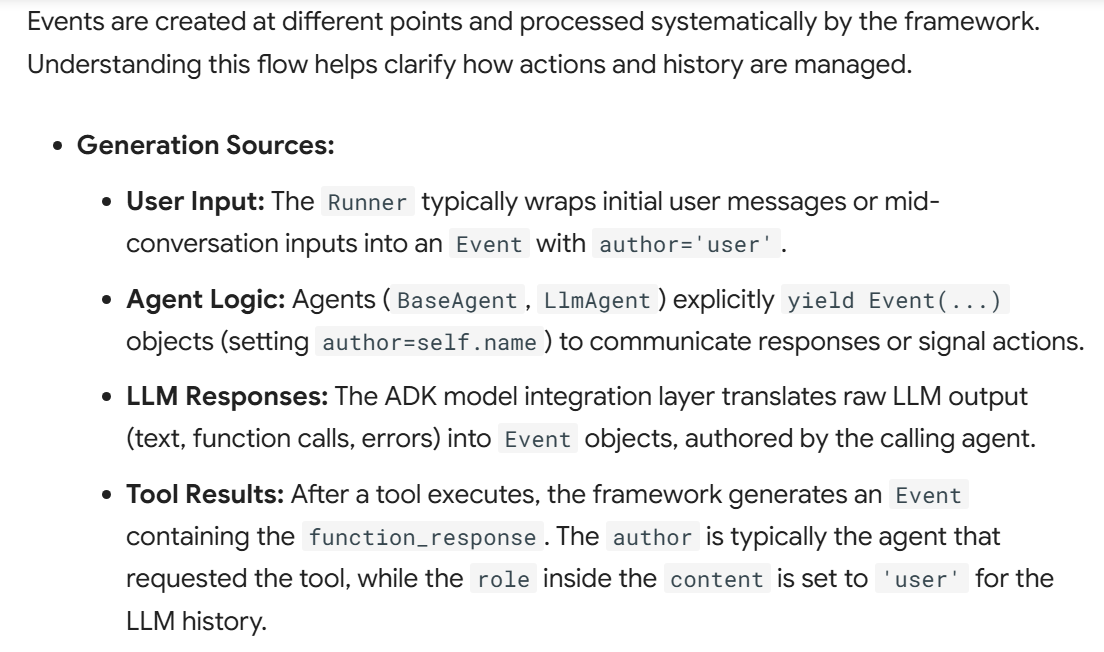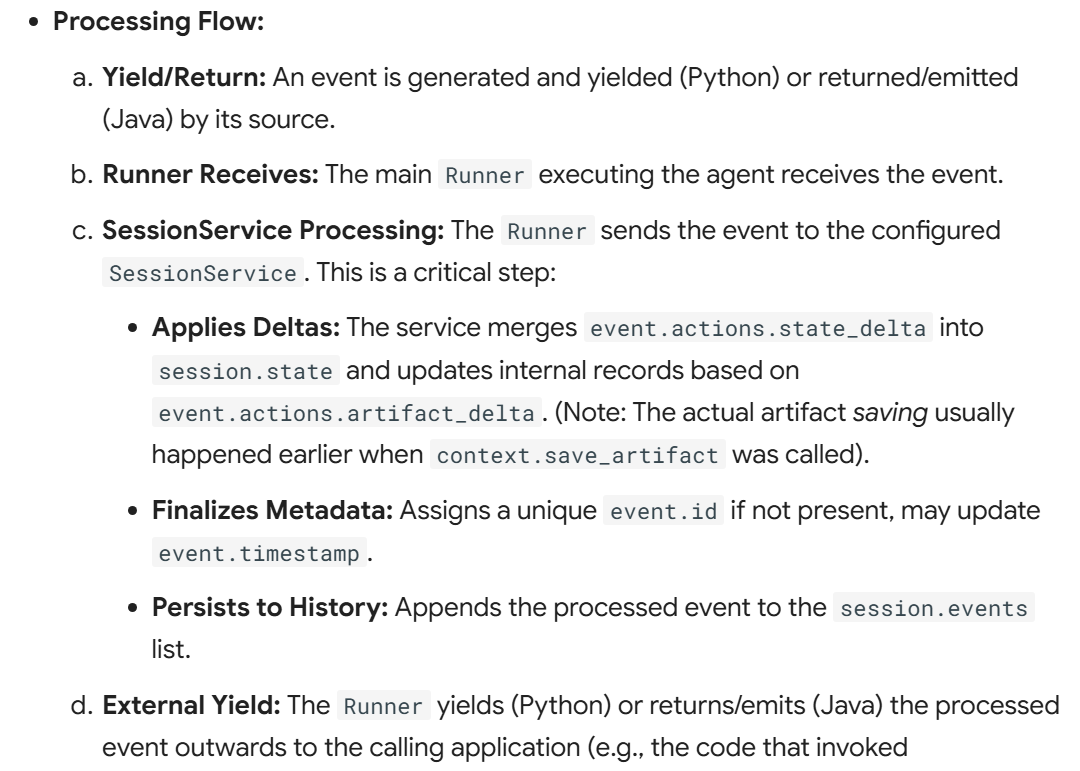

> This flow ensures that state changes and history are consistently recorded alongside the communication content of each event.

## Common Event Examples (Illustrative Patterns)
Here are concise examples of typical events you might see in the stream:

- **User Input**
```Python
{
  "author": "user",
  "invocation_id": "e-xyz...",
  "content": {"parts": [{"text": "Book a flight to London for next Tuesday"}]}
  // actions usually empty
}
```

- **Agent Final Text Response:** `(is_final_response() == True)`
```Python
{
  "author": "TravelAgent",
  "invocation_id": "e-xyz...",
  "content": {"parts": [{"text": "Okay, I can help with that. Could you confirm the departure city?"}]},
  "partial": false,
  "turn_complete": true
  // actions might have state delta, etc.
}
```

- **Agent Streaming Text Response:** `(is_final_response() == False)`
```Python
{
  "author": "SummaryAgent",
  "invocation_id": "e-abc...",
  "content": {"parts": [{"text": "The document discusses three main points:"}]},
  "partial": true,
  "turn_complete": false
}
// ... more partial=True events follow ...
```

- **Tool Call Request (by LLM):** ``(is_final_response() == False)`
```Python
{
  "author": "TravelAgent",
  "invocation_id": "e-xyz...",
  "content": {"parts": [{"function_call": {"name": "find_airports", "args": {"city": "London"}}}]}
  // actions usually empty
}
```

- **Tool Result Provided (to LLM):** (`is_final_response()` depends on `skip_summarization`)

```Python
{
  "author": "TravelAgent", // Author is agent that requested the call
  "invocation_id": "e-xyz...",
  "content": {
    "role": "user", // Role for LLM history
    "parts": [{"function_response": {"name": "find_airports", "response": {"result": ["LHR", "LGW", "STN"]}}}]
  }
  // actions might have skip_summarization=True
}
```

- **State/Artifact Update Only:** (`is_final_response() == False`)

```Python
{
  "author": "InternalUpdater",
  "invocation_id": "e-def...",
  "content": null,
  "actions": {
    "state_delta": {"user_status": "verified"},
    "artifact_delta": {"verification_doc.pdf": 2}
  }
}
```

- **Agent Transfer Signal:** (`is_final_response() == False`)

```Python
{
  "author": "OrchestratorAgent",
  "invocation_id": "e-789...",
  "content": {"parts": [{"function_call": {"name": "transfer_to_agent", "args": {"agent_name": "BillingAgent"}}}]},
  "actions": {"transfer_to_agent": "BillingAgent"} // Added by framework
}
```

- **Loop Escalation Signal:** (`is_final_response() == False`)

```Python
{
  "author": "CheckerAgent",
  "invocation_id": "e-loop...",
  "content": {"parts": [{"text": "Maximum retries reached."}]}, // Optional content
  "actions": {"escalate": true}
}
```

----

## Additional Context and Event Details
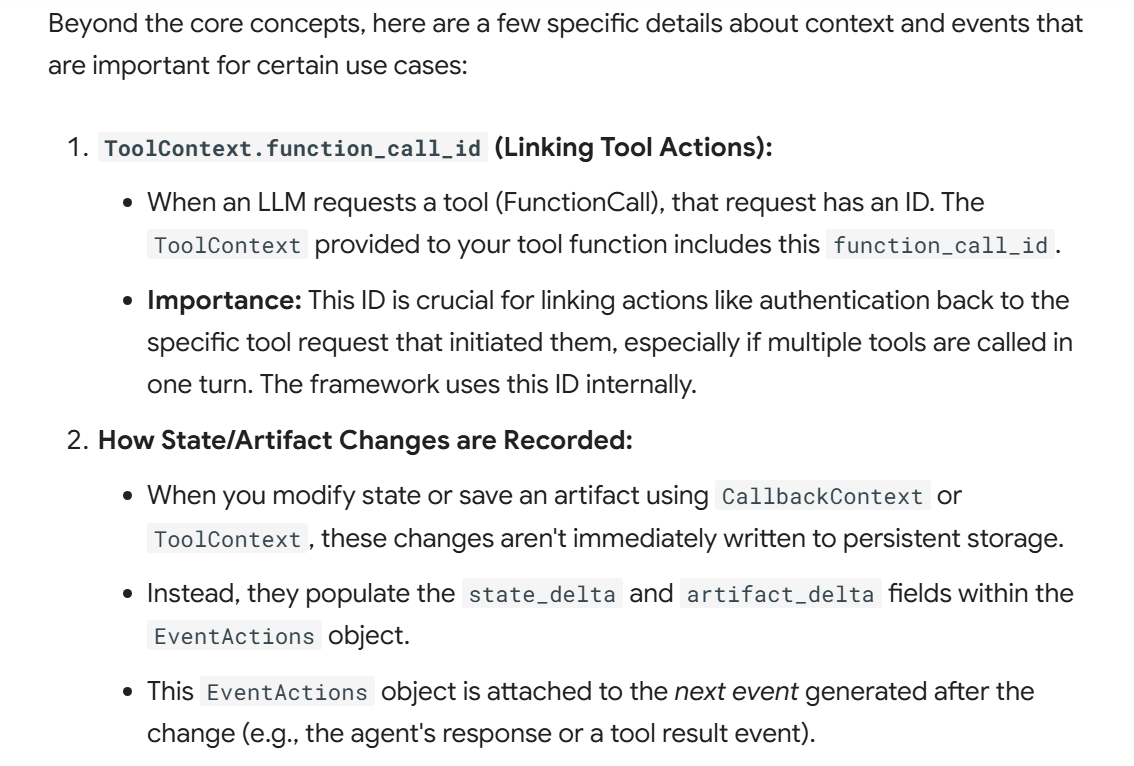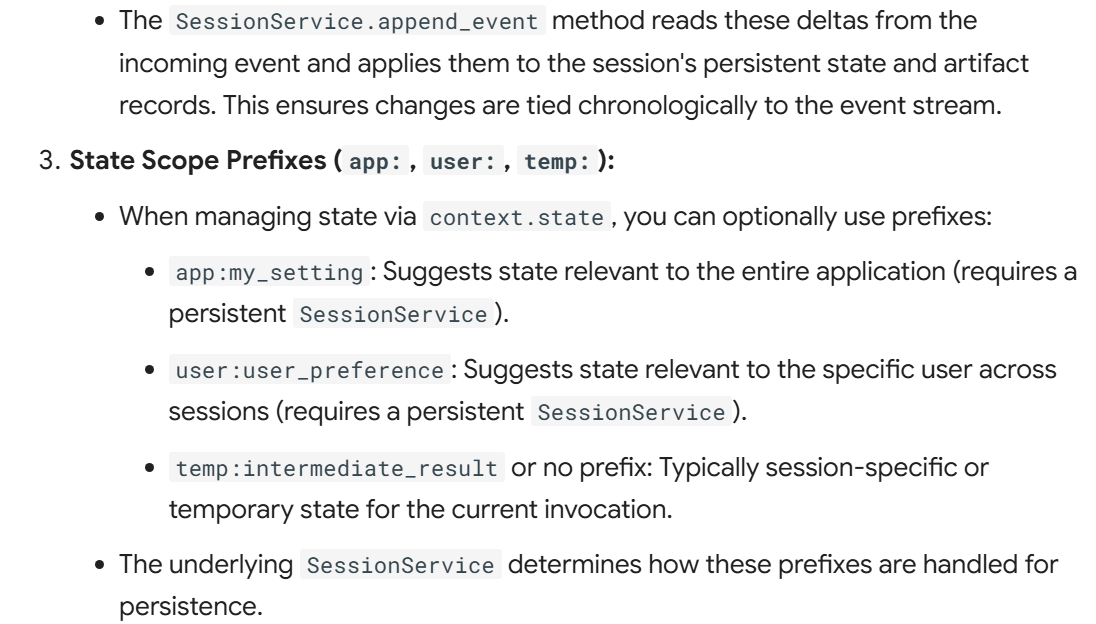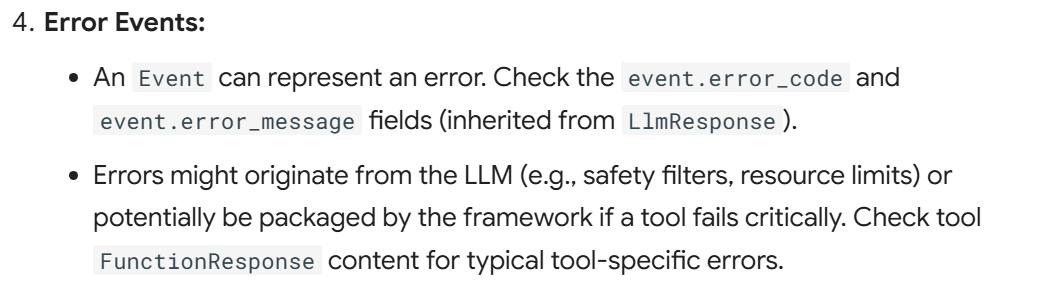 <br><br> 

```Python
// Example Error Event (conceptual)
{
  "author": "LLMAgent",
  "invocation_id": "e-err...",
  "content": null,
  "error_code": "SAFETY_FILTER_TRIGGERED",
  "error_message": "Response blocked due to safety settings.",
  "actions": {}
}
```

> These details provide a more complete picture for advanced use cases involving tool authentication, state persistence scope, and error handling within the event stream.

---

## Best Practices for Working with Events
To use events effectively in your ADK applications:
- **Clear Authorship:** When building custom agents, ensure correct attribution for agent actions in the history. The framework generally handles authorship correctly for LLM/tool events.

```Python
Use yield Event(author=self.name, ...) in BaseAgent subclasses.
```

- **Semantic Content & Actions:** Use `event.content` for the core message/data (text, function call/response). Use `event.actions` specifically for signaling side effects (state/artifact deltas) or control flow (`transfer`, `escalate`, `skip_summarization`).

- **Idempotency Awareness:** Understand that the `SessionService` is responsible for applying the state/artifact changes signaled in `event.actions`. While ADK services aim for consistency, consider potential downstream effects if your application logic re-processes events.

- **Use `is_final_response()`:** Rely on this helper method in your application/UI layer to identify complete, user-facing text responses. Avoid manually replicating its logic.

- **Leverage History:** The session's event list is your primary debugging tool. Examine the sequence of authors, content, and actions to trace execution and diagnose issues.

- **Use Metadata:** Use `invocation_id` to correlate all events within a single user interaction. Use `event.id` to reference specific, unique occurrences.

<br>

> Treating events as structured messages with clear purposes for their content and actions is key to building, debugging, and managing complex agent behaviors in `ADK`.

---